이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib

- 실습 기본 환경 설정


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()

CUDA를 사용합니다.


# 7-4 잠재 공간과 전이 학습

본 노트북은 본문 7-4절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 오토인코더에서 잠재 벡터를 꺼내는 방법과 잠재 공간 시각화([그림 7-11])
- 인코더를 재활용하는 특징 추출 방식과 미세 조정 방식의 전이 학습 분류기
- 계층마다 다른 학습률을 적용하는 옵티마이저
- 두 전이 학습 방식의 학습 결과 비교([표 7-3])와 혼동 행렬([그림 7-13])
- [연습 문제 7-15]에서 필요한, 어휘 사전이 다를 때의 임베딩 행렬 재구성

본문의 모델 10a의 구현에 해당되며, 모델 10a의 제시문은 다음과 같다.

> **모델 10a. MNIST 오토인코더를 재활용해 만든 숫자 분류기**
>
> 학습된 오토인코더(모델 10)로 MNIST 데이터셋을 분류하는 숫자 분류기를 만든다. 숫자 분류기 모델의 파라미터를 무작위로 초기화하는 대신 오토인코더 속 파라미터 값을 재활용한다.

## 사전 학습 모델 준비

- 본 노트북은 7-3절 노트북과 독립적으로 동작해야 하므로, 사전 학습된 오토인코더를 같은 환경으로 다시 학습한다.
    - 모델 정의, 데이터 준비, 학습 함수는 모두 7-3절과 같다. 설명은 7-3절 노트북(`07-03_example.ipynb`)을 참고하자.

In [2]:
# 참고 - 7-3절의 오토인코더 모델(Z_SIZE=2)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# 오토인코더 모델 정의
class MNISTAutoEncoder(nn.Module):
    def __init__(self, z_size=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),      # (B, 784) -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 64),           #          -> (B, 64)
            nn.ReLU(),
            nn.Linear(64, z_size),        #          -> (B, z_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(z_size, 64),        # (B, z_size) -> (B, 64)
            nn.ReLU(),
            nn.Linear(64, 128),           #             -> (B, 128)
            nn.ReLU(),
            nn.Linear(128, 28 * 28),      #             -> (B, 784)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)               # 인코더: (B, 784) -> (B, z_size)로 압축
        return self.decoder(z)            # 디코더: (B, z_size) -> (B, 784)로 복원



# 데이터 변환 객체: 텐서 변환, 평탄화
transform_chain = transforms.Compose([
    transforms.ToTensor(), 
    nn.Flatten(start_dim=0)
])

# MNIST 데이터셋과 데이터로더

# data_root: MNIST 데이터셋 다운로드 경로
data_root = '../../download'

mnist_full = datasets.MNIST(root=data_root, train=True, download=True, transform=transform_chain)
train_set, valid_set = random_split(
    mnist_full, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED),
)

test_set = datasets.MNIST(root=data_root, train=False, download=True, transform=transform_chain)

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):    
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in train_loader:           # 정답 레이블은 사용하지 않음
        inputs = inputs.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)              # 입력 배치 텐서로 예측
        loss = criterion(outputs, inputs)    # 입력 배치 텐서를 정답으로 사용
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


# 전체 에포크 학습 함수(조기 종료 방식)
def train(model, train_loader, valid_loader, criterion, optimizer,
               epochs, device, patience=5):
    model.to(device)
    # 표준 학습 로거 설정
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실'),
        formats=('{:.4f}', '{:.4f}'),
    )
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_state = None
    patience_counter = 0
    
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 1 에포크 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss = evaluate(model, valid_loader, criterion, device)
        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss, valid_loss)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            # detach().clone()을 사용해도 분리된 파라미터 저장 가능
            best_state = {k: v.detach().clone()
                          for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:                
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_valid_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    return log


# 결과 재현 및 고정을 위한 시드 재설정
common.set_seed()

# 학습 환경
Z_SIZE = 2                  # 잠재 벡터의 크기
LR = 0.001                  # 학습률
PATIENCE = 5                # 조기 종료 인내
EPOCHS = 100                # 상한. 조기 종료로 더 일찍 끝남.

model = MNISTAutoEncoder(z_size=Z_SIZE).to(device)
criterion = nn.MSELoss()                     # 평균제곱오차 손실
optimizer = optim.Adam(model.parameters(), lr=LR)

# 모델 학습
log = train(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, device, patience=PATIENCE
)

 에포크    훈련 손실    검증 손실     시간
  1/100       0.0662       0.0537     0:06


 10/100       0.0419       0.0419     0:53


 20/100       0.0390       0.0395     1:45


 30/100       0.0378       0.0384     2:38


 40/100       0.0368       0.0379     3:31


 50/100       0.0363       0.0378     4:24


 60/100       0.0360       0.0374     5:16


 70/100       0.0356       0.0373     6:09


최적 69 에포크 모델(검증 손실: 0.0372)로 복원


## 잠재 벡터 구하기

- 모델을 정의할 때 인코더를 따로 묶어 두었으므로, 인코더만 호출하면 잠재 벡터를 얻을 수 있다.

In [3]:
######################################################################################
# 코드 7-7 - 잠재 벡터 구하기
######################################################################################

# 오토인코더(model)의 잠재 벡터를 반환하는 함수
def get_z_vector(model, inputs, device):
    model.eval()
    inputs = inputs.to(device)
    with torch.no_grad():
        # 모델을 정의할 때 인코더를 따로 묶어두면 잠재 벡터를 쉽게 구할 수 있음
        z_vector = model.encoder(inputs) # 잠재 벡터: 인코더의 출력
    return z_vector

# MNIST 평가 데이터셋의 첫 번째 이미지 샘플 텐서
test_sample = test_set[0][0]
z = get_z_vector(model, test_sample, device)
x, y = z[0].item(), z[1].item()
print(f'샘플 입력 텐서가 압축된 잠재 벡터: ({x}, {y})')

샘플 입력 텐서가 압축된 잠재 벡터: (1.5656195878982544, -5.406754016876221)


- 출력 결과는 두 개의 실수로 구성된다. 모델 객체를 만들 때 잠재 벡터의 크기(`Z_SIZE`)를 2로 정했기 때문이다.
    - 본문은 지면에 맞춰 `0.55, -5.00`처럼 소수점 두 자리로 줄인 출력 예시를 싣고 있다.

## 잠재 벡터의 분포와 잠재 공간([그림 7-11])

- 잠재 벡터가 두 개의 실수이므로 좌표평면 위의 한 점으로 나타낼 수 있다.
- 평가 데이터셋에서 1, 6, 9 샘플 100개씩(왼쪽)과 7, 9 샘플 100개씩(오른쪽)의 잠재 벡터를 좌표평면에 그린다.
    - 숫자별 전체 샘플의 90% 분포 영역을 타원으로 함께 표시한다.

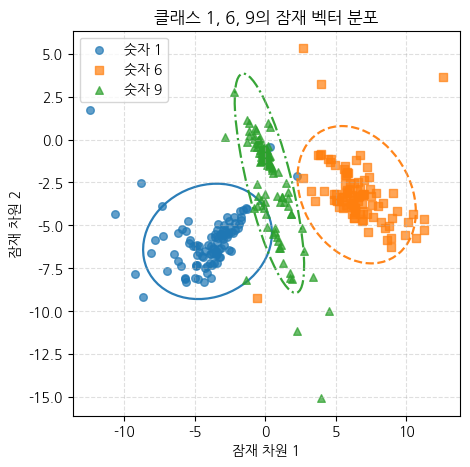

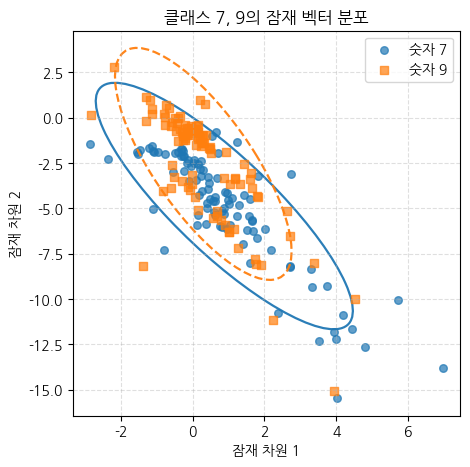

In [4]:
# 참고 - 잠재 벡터 분포 시각화([그림 7-11])
import numpy as np

# 각 클래스에서 num_per_class개의 샘플에 대응하는 잠재 벡터를 수집
def collect_z_by_class(model, dataset, classes, num_per_class, device):
    model.eval()
    collected = {c: [] for c in classes}
    with torch.no_grad():
        for img, label in dataset:
            if label in collected and len(collected[label]) < num_per_class:
                z = model.encoder(img.unsqueeze(0).to(device))[0].cpu()
                collected[label].append(z)
            if all(len(v) >= num_per_class for v in collected.values()):
                break
    return collected

# 왼쪽 그림: 1, 6, 9 각 100 샘플의 잠재 벡터 시각화
classes_left = [1, 6, 9]
data_left = collect_z_by_class(model, test_set, classes_left, 100, device)

X_left = np.array([z.numpy() for c in classes_left for z in data_left[c]])
y_left = np.array([
    classes_left.index(c) for c in classes_left for _ in range(100)
])

viz.plot_scatter(
    X_left, y_left,
    title='클래스 1, 6, 9의 잠재 벡터 분포',
    x_label='잠재 차원 1', y_label='잠재 차원 2',
    class_names=[f'숫자 {c}' for c in classes_left],
    add_ellipses=True, ellipse_confidence=0.90,
    figsize=(5, 5)
)

# 오른쪽 그림: 7, 9 각 100 샘플의 잠재 벡터 시각화
classes_right = [7, 9]
data_right = collect_z_by_class(model, test_set, classes_right, 100, device)

X_right = np.array([z.numpy() for c in classes_right for z in data_right[c]])
y_right = np.array([
    classes_right.index(c) for c in classes_right for _ in range(100)
])

viz.plot_scatter(
    X_right, y_right,
    title='클래스 7, 9의 잠재 벡터 분포',
    x_label='잠재 차원 1', y_label='잠재 차원 2',
    class_names=[f'숫자 {c}' for c in classes_right],
    add_ellipses=True, ellipse_confidence=0.90,
    figsize=(5, 5)
)

- 왼쪽 그림에서는 같은 숫자끼리 군집을 이루고 서로 다른 군집은 대체로 분리된다.
    - 학습 과정에서 '이 이미지는 1이다'라고 알려준 적이 없는데도, 인코더가 입력을 재현하는 데 가장 필요한 정보가 이미지에 그려진 숫자라는 사실을 스스로 발견한 셈이다.
- 오른쪽 그림에서 7과 9의 군집은 거의 같은 영역을 공유한다.
    - 크기 2의 잠재 벡터로는 모양이 비슷한 숫자의 차이까지 담아낼 여지가 부족하다.
- 이렇게 잠재 벡터가 만들어 내는 군집과 분포의 구조를 잠재 공간이라고 한다.
    - 좌표평면은 잠재 벡터를 그리기 위한 캔버스일 뿐, 잠재 공간은 그 위에 떠오른 구조 그 자체다.

In [5]:
# 재현성 보장을 위한 시드 고정
common.set_seed(SEED)

42

## 전이 학습 분류기 모델

- 오토인코더의 인코더는 숫자를 구분할 수는 있지만 구분한 숫자가 무엇인지는 알 수 없으므로 분류기 계층을 추가해야 한다.
- 두 부분에 주목하자.
    - 인코더의 모든 파라미터를 순회하면서 `requires_grad`를 `False`로 지정한다. 이렇게 고정한 파라미터는 자동 미분 대상이 되지 않아 옵티마이저가 값을 바꾸지 않는다(특징 추출 방식).
    - `nn.Linear(z_size, 10)`으로 분류기 계층을 추가한다. 인코더는 잠재 벡터를 만드는 역할만 하기 때문이다.
- `copy.deepcopy()`로 인코더를 깊은 복사하는 것은 원본 오토인코더를 그대로 유지하기 위함이다.

In [6]:
######################################################################################
# 코드 7-8 - 특징 추출 방식의 전이 학습 모델
######################################################################################

import copy, torchinfo
# 특징 추출 방식으로 오토인코더의 인코더를 재활용하는 분류기 클래스
class ClassifierWithFeatureExtractor(nn.Module):
    def __init__(self, encoder, z_size):
        super().__init__()
        # 사전 학습된 오토인코더의 인코더(원본 보존을 위한 깊은 복사)
        self.encoder = copy.deepcopy(encoder)
        # 파라미터 고정(고정하지 않으면 미세 조정 방식의 전이 학습)
        for param in self.encoder.parameters():
            param.requires_grad = False
        # 숫자 분류를 위한 분류기 계층 추가(10개 클래스로 분류)
        self.classifier = nn.Linear(z_size, 10)

    def forward(self, x):                    # 입력 x: (B, 784)
        z_vector = self.encoder(x)           #    -> (B, Z_SIZE)
        return self.classifier(z_vector)     #    -> (B, 10)


# 사전 학습된 모델의 인코더(model.encoder)를 주입해 모델 객체 생성(z_size=2)
#     model: 7-3절에서 학습한 MNIST 오토인코더
model_fe = ClassifierWithFeatureExtractor(model.encoder, Z_SIZE).to(device)

# 옵티마이저: 모델의 parameters()에는 인코더의 파라미터도 포함되지만,
# requires_grad=False로 고정되어 있으므로 최적화되지 않음
optimizer_fe = optim.Adam(model_fe.parameters(), lr=LR)

# 모델 구조 확인: 배치 크기를 10으로 가정
torchinfo.summary(model_fe, input_size=(10, 784), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ClassifierWithFeatureExtractor           [10, 10]                  --
├─Sequential: 1-1                        [10, 2]                   --
│    └─Linear: 2-1                       [10, 128]                 (100,480)
│    └─ReLU: 2-2                         [10, 128]                 --
│    └─Linear: 2-3                       [10, 64]                  (8,256)
│    └─ReLU: 2-4                         [10, 64]                  --
│    └─Linear: 2-5                       [10, 2]                   (130)
├─Linear: 1-2                            [10, 10]                  30
Total params: 108,896
Trainable params: 30
Non-trainable params: 108,866
Total mult-adds (Units.MEGABYTES): 1.09
Input size (MB): 0.03
Forward/backward pass size (MB): 0.02
Params size (MB): 0.44
Estimated Total Size (MB): 0.48

> `torchinfo.summary()`의 출력에서 파라미터 수가 `(100,480)`처럼 괄호로 묶인 것은 고정되어 학습되지 않는 파라미터를 뜻한다. 고정하지 않은 분류기 계층의 파라미터 수는 괄호 없이 출력된다.

- 비교를 위해서 인코더의 파라미터를 고정하지 않는 미세 조정 방식의 분류기도 정의한다.
    - `requires_grad`를 고정하는 부분만 없애면 된다.

In [7]:
# 참고 - 미세 조정 방식의 전이 학습 분류기

# 미세 조정 방식으로 오토인코더의 인코더를 재활용하는 분류기 클래스
class ClassifierWithFineTuning(nn.Module):
    def __init__(self, encoder, z_size):
        super().__init__()
        self.encoder = copy.deepcopy(encoder)
        # 인코더의 파라미터도 최적화하므로 requires_grad=False 로 고정하지 않는다.
        self.classifier = nn.Linear(z_size, 10)

    def forward(self, x):                    # 입력 x: (B, 784)
        z_vector = self.encoder(x)           #      -> (B, z_size)
        return self.classifier(z_vector)     #      -> (B, 10)


# 모델 객체 생성
model_ft = ClassifierWithFineTuning(model.encoder, Z_SIZE).to(device)

## 계층마다 다른 학습률

- 미세 조정 방식에서 학습률은 주의가 필요하다.
    - 일반 모델처럼 학습률을 정하면 애써 학습한 사전 학습 모델의 파라미터가 지나치게 크게 변한다.
    - 반대로 학습률을 낮추면 추가한 계층의 학습이 느려진다.
- 그래서 사전 학습 계층은 매우 작은 값(보통 1e-5 수준), 추가한 계층은 평소 수준의 값(보통 1e-3 수준)을 적용한다.
    - 파라미터 그룹별 학습률을 담은 딕셔너리의 리스트를 옵티마이저에 넘기면 된다.

In [8]:
######################################################################################
# 코드 7-9 - 계층마다 다른 학습률을 적용하는 미세 조정 학습용 옵티마이저 생성
######################################################################################

LR_FT = 1e-5                 # 사전 학습된 계층에 적용할 학습률

# 미세 조정 방식의 옵티마이저
optimizer_ft = optim.Adam(
    [
        # 사전 학습된 계층의 파라미터는 낮은 학습률 지정
        {'params': model_ft.encoder.parameters(), 'lr': LR_FT},
        # 추가 계층의 파라미터는 통상 학습률 지정
        {'params': model_ft.classifier.parameters(), 'lr': LR},
    ]
)

## 전이 학습용 데이터 준비와 학습

- 적은 데이터로 좋은 성능을 낼 수 있다는 전이 학습의 장점을 체감할 수 있도록 100개의 샘플만 학습에 사용한다.
    - MNIST의 기본 훈련 데이터셋은 오토인코더 학습에 이미 사용했으므로, 평가 데이터셋을 100개, 100개, 9,800개로 나눠 훈련, 검증, 평가 용도로 사용한다.
    - 인코더가 표준화 변환 없이 학습되었으므로 데이터 변환 객체도 7-3절의 것을 그대로 사용한다.

In [9]:
# 참고 - 전이 학습용 데이터 준비

# 소량의 데이터에서 전이 학습 효과 확인을 위해 훈련 데이터셋과 검증 데이터셋을 각 100 샘플씩만 사용
# 훈련 데이터셋, 검증 데이터셋은 이미 사전 학습 모델을 만드는데 사용했기 때문에, 이번에는 평가 데이터셋을 나눠 사용함
# 전이 학습용 데이터셋 생성
split_sizes = [100, 100, 9800]          # 학습, 검증, 평가 데이터셋의 샘플 수

# test_set: 7-3 절의 데이터 변환 객체를 적용한 MNIST 기본 평가 데이터셋
train_set_tl, valid_set_tl, test_set_tl = random_split(
    test_set, split_sizes,
    generator=torch.Generator().manual_seed(SEED),
)

BATCH_SIZE_TL = 10                      # 배치 크기

# 전이 학습용 데이터로더
train_loader_tl = DataLoader(train_set_tl, batch_size=BATCH_SIZE_TL, shuffle=True)
valid_loader_tl = DataLoader(valid_set_tl, batch_size=BATCH_SIZE_TL, shuffle=False)
test_loader_tl  = DataLoader(test_set_tl,  batch_size=BATCH_SIZE_TL, shuffle=False)

- 전이 학습의 목표가 숫자 분류이므로 손실 함수는 교차 엔트로피 손실 함수(`nn.CrossEntropyLoss`)를 사용한다.
    - 분류 모델용 학습 함수를 정의해 두 모델을 같은 환경으로 학습한다.

In [10]:
# 참고 - 분류 모델용 학습 함수(조기 종료 포함)
def train_epoch_cls(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (logits.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size * 100

@torch.no_grad()
def evaluate_cls(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (logits.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size * 100


def train_loop_cls(model, train_loader, valid_loader, criterion, optimizer,
                   epochs, device, patience=20):
    if device is None:
        device = torch.device('cpu')
    model.to(device)
    log = common.EpochLogger(
        epochs, columns=('훈련 손실', '검증 손실', '정확도(%)'),
        formats=('{:.4f}', '{:.4f}', '{:.2f}%'),
    )
    best_loss = float('inf')
    best_epoch = -1
    best_state = None
    counter = 0
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch_cls(
            model, train_loader, criterion, optimizer, device,
        )
        valid_loss, valid_acc = evaluate_cls(
            model, valid_loader, criterion, device,
        )
        log.row(epoch, train_loss, valid_loss, valid_acc)
        # 정확도 비교용으로 훈련 정확도도 별도로 모아 둠
        log.train_accs = getattr(log, 'train_accs', [])
        log.train_accs.append(train_acc)
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_epoch = epoch
            best_state = {k: v.clone()
                          for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break
    if best_state is not None:
        print(f'최적 {best_epoch} 에포크 모델(검증 손실: {best_loss:.4f})로 복원')
        model.load_state_dict(best_state)
    log.best_epoch = best_epoch
    log.best_loss = best_loss
    return log

특징 추출 방식 전이 학습
   에포크    훈련 손실    검증 손실    정확도(%)     시간
   1/1000       3.5916       2.9036       28.00%     0:00


 100/1000       1.5236       1.6756       41.00%     0:03


 200/1000       1.4331       1.6165       50.00%     0:07


 300/1000       1.3851       1.5823       50.00%     0:10


 400/1000       1.3536       1.5606       50.00%     0:14


 500/1000       1.3313       1.5468       50.00%     0:17


 600/1000       1.3147       1.5381       51.00%     0:21


 700/1000       1.3032       1.5311       52.00%     0:24


 800/1000       1.2935       1.5283       51.00%     0:27


최적 829 에포크 모델(검증 손실: 1.5264)로 복원


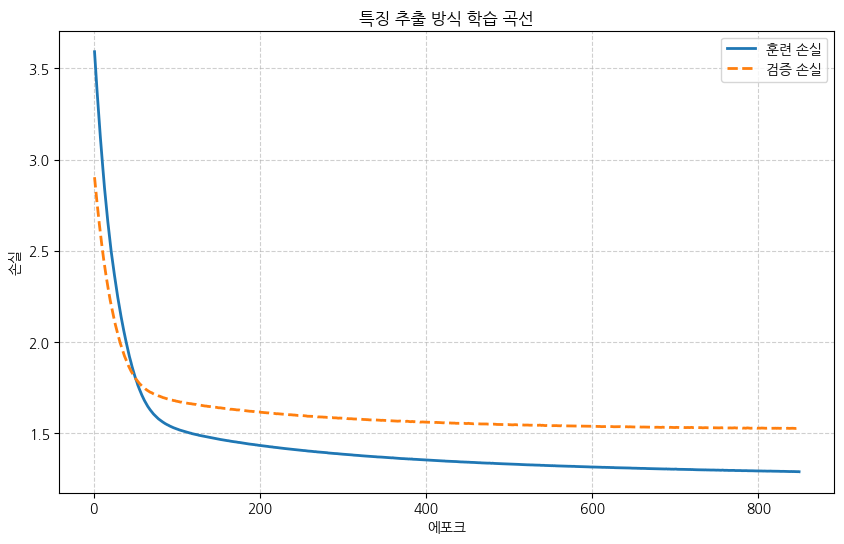

미세 조정 방식 전이 학습
 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/500       4.3667       3.9242       15.00%     0:00


 50/500       2.2406       2.3113       25.00%     0:02


100/500       1.6484       1.8783       38.00%     0:05


150/500       1.4537       1.7276       45.00%     0:07


200/500       1.3103       1.6190       49.00%     0:09


...

300/500       1.0567       1.4384       51.00%     0:14


350/500       0.9339       1.3692       52.00%     0:16


400/500       0.8245       1.3237       50.00%     0:18


450/500       0.7350       1.3048       52.00%     0:21


최적 471 에포크 모델(검증 손실: 1.3017)로 복원


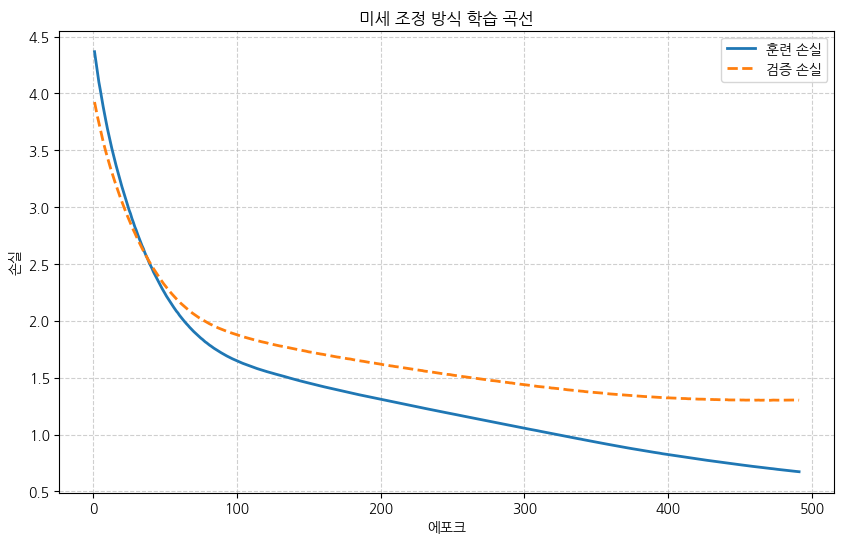

In [11]:
# 참고 - 두 전이 학습 모델 학습
# 본문 [표 7-3]의 최적 에포크(712, 363)를 고려해 에포크 상한을 1,000과 500으로 설정
common.set_seed()

criterion_cls = nn.CrossEntropyLoss()

print('특징 추출 방식 전이 학습')
log_fe = train_loop_cls(
    model_fe, train_loader_tl, valid_loader_tl, criterion_cls, optimizer_fe,
    epochs=1000, device=device, patience=20
)
log_fe.plot(title='특징 추출 방식 학습 곡선')

# 미세 조정 모델은 옵티마이저 재생성 (학습률 그룹 적용)
optimizer_ft = optim.Adam(
    [
        {'params': model_ft.encoder.parameters(), 'lr': LR_FT},
        {'params': model_ft.classifier.parameters(), 'lr': LR}
    ]
)
print('미세 조정 방식 전이 학습')
log_ft = train_loop_cls(
    model_ft, train_loader_tl, valid_loader_tl, criterion_cls, optimizer_ft,
    epochs=500, device=device, patience=20
)
log_ft.plot(title='미세 조정 방식 학습 곡선')

In [12]:
# 참고 - 두 학습 방식의 평가 비교
fe_test_loss, fe_test_acc = evaluate_cls(
    model_fe, test_loader_tl, criterion_cls, device,
)
ft_test_loss, ft_test_acc = evaluate_cls(
    model_ft, test_loader_tl, criterion_cls, device,
)

print('--- 두 전이 학습 방식의 결과 ---')
header = (f'{"방식":>10s} | {"최적":>3s} | {"훈련손실":>4s} | '
         f'{"검증손실":>4s} | {"훈련정확도":>5s} | {"평가정확도":>5s}')
print(header)
print('-' * 70)
# 각 EpochLogger가 누적한 이력(log.history)에서 최적 에포크 시점의 값을 꺼낸다.
fe_train_loss = log_fe.history['훈련 손실'][log_fe.best_epoch - 1]
fe_train_acc = log_fe.train_accs[log_fe.best_epoch - 1]
print(f'{"특징 추출":>8s} | {log_fe.best_epoch:>5d} | '
      f'{fe_train_loss:>8.4f} | {log_fe.best_loss:>8.4f} | '
      f'{fe_train_acc:>9.2f}% | {fe_test_acc:>9.2f}%')
ft_train_loss = log_ft.history['훈련 손실'][log_ft.best_epoch - 1]
ft_train_acc = log_ft.train_accs[log_ft.best_epoch - 1]
print(f'{"미세 조정":>8s} | {log_ft.best_epoch:>5d} | '
      f'{ft_train_loss:>8.4f} | {log_ft.best_loss:>8.4f} | '
      f'{ft_train_acc:>9.2f}% | {ft_test_acc:>9.2f}%')

--- 두 전이 학습 방식의 결과 ---
        방식 |  최적 | 훈련손실 | 검증손실 | 훈련정확도 | 평가정확도
----------------------------------------------------------------------
   특징 추출 |   829 |   1.2913 |   1.5264 |     57.00% |     54.11%
   미세 조정 |   471 |   0.7022 |   1.3017 |     73.00% |     57.79%


- 본문 [표 7-3]의 수치(특징 추출 712 에포크 / 훈련 60.00% / 평가 56.51%, 미세 조정 363 에포크 / 훈련 67.00% / 평가 57.85%)와 비교해 보자.
    - 시드와 환경 차이로 정확히 일치하지 않을 수 있지만, 두 방식 모두 100개의 샘플에서 50~60%대 정확도를 낸다는 결론은 같다.

## 두 모델의 혼동 행렬([그림 7-13])

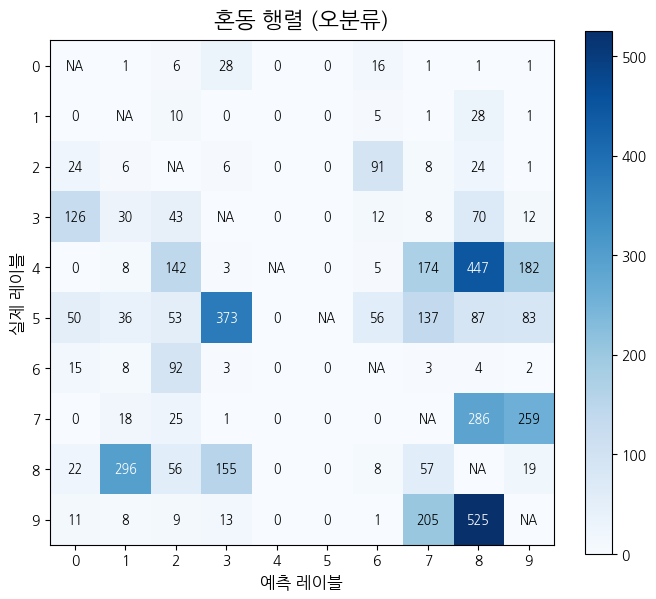

In [13]:
# 참고 - 두 모델의 혼동 행렬 ([그림 7-13])
cm_fe = common.get_confusion_matrix(
    model_fe, test_loader_tl, num_classes=10, device=device,
)

viz.plot_confusion_matrix(
    cm_fe, class_names=list('0123456789'),
    show_errors_only=True
)

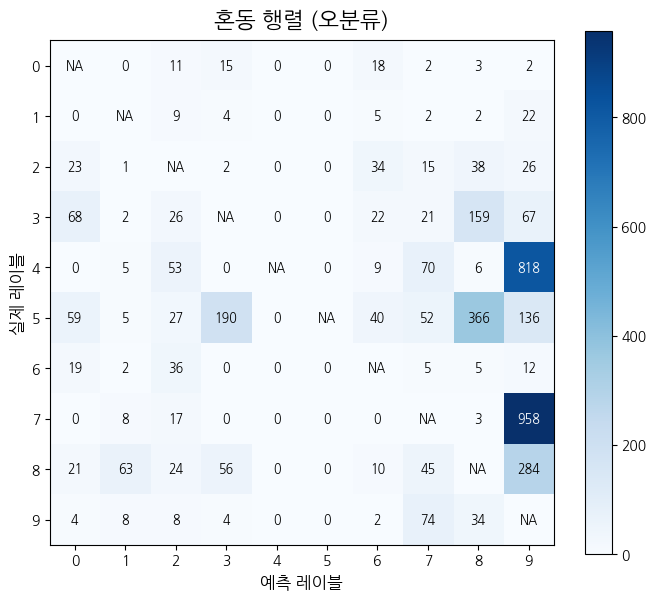

In [14]:
# 참고 - 미세 조정 모델의 혼동 행렬
cm_ft = common.get_confusion_matrix(
    model_ft, test_loader_tl, num_classes=10, device=device,
)
viz.plot_confusion_matrix(
    cm_ft, class_names=list('0123456789'),
    show_errors_only=True
)

- 두 혼동 행렬에서 다음 패턴을 관찰할 수 있다.
    - 숫자 7은 대부분 9로, 4는 9로, 5는 3이나 8로 오분류되는 등 형태가 닮은 숫자끼리 혼동이 많다. [그림 7-11] 오른쪽 그래프의 군집 겹침이 그대로 반영된 결과다.
    - 1, 6, 9끼리의 오분류는 상대적으로 빈도가 낮다. 특히 숫자 1은 형태가 단순해 크기 2의 잠재 벡터에도 핵심 정보가 잘 보존된다.
- 미세 조정은 인코더까지 다시 학습해 잠재 공간을 분류 목적에 맞게 재배치하므로, 혼동이 일어나는 숫자 쌍 자체가 달라진다.
    - 크기 2의 좁은 잠재 공간에서는 혼동의 총량이 줄어들기보다 자리만 옮겨 가는 셈이다.

- 성능이 낮은 또 다른 원인은 훈련 데이터셋이 지나치게 작고 불균형이 심하다는 점이다.
    - 클래스가 10개인 분류 문제에서 100개의 샘플은 클래스당 평균 10개에 불과하다.

In [15]:
# 참고 - 훈련 데이터셋 클래스별 샘플 수
from collections import Counter

label_counts = Counter(int(train_set_tl[i][1]) for i in range(len(train_set_tl)))
print('--- 훈련 데이터셋 클래스별 샘플 수 ---')
for cls in sorted(label_counts):
    print(f'  숫자 {cls}: {label_counts[cls]:,}')
print(f'  합계: {sum(label_counts.values()):,}')

--- 훈련 데이터셋 클래스별 샘플 수 ---
  숫자 0: 11
  숫자 1: 14
  숫자 2: 12
  숫자 3: 6
  숫자 4: 8
  숫자 5: 8
  숫자 6: 11
  숫자 7: 9
  숫자 8: 11
  숫자 9: 10
  합계: 100


- 무작위로 분리한 결과 숫자별 샘플 수의 차이가 크게 벌어진다.
    - [연습 문제 7-11]과 [연습 문제 7-12]에서 이 두 제약을 풀어 보면 전이 학습이 가진 본래의 힘을 확인할 수 있다.

## 참고 - 어휘 사전이 다를 때 임베딩 행렬 재구성([연습 문제 7-15])

- [연습 문제 7-15]는 7-2절에서 <오즈의 마법사>로 학습한 임베딩을 <이상한 나라의 앨리스> 학습에 재활용하는 도전 문제다.
    - 본문은 어휘 사전을 재구성하고 그 순서에 맞게 임베딩 행렬도 재구성해야 한다고 안내하며, 그 과정을 이 노트북에 정리한다고 미뤘다.
- 핵심은 두 텍스트의 토큰 구성이 달라 어휘 사전의 순서가 바뀐다는 점이다.
    - 임베딩 행렬은 '행 번호 = 토큰 고유 번호' 규칙으로 동작하므로, 어휘 순서가 바뀌면 같은 토큰이라도 담당하는 행이 달라진다.
- 따라서 사전 학습된 임베딩을 그대로 쓸 수 없고 다음과 같이 행을 재배치해야 한다.
    - **두 어휘에 공통인 토큰**: 사전 학습된 행(벡터)을 새 어휘 순서의 위치로 그대로 이식한다.
    - **새 텍스트에만 있는 토큰**: 대응하는 사전 학습 벡터가 없으므로 무작위로 초기화하고 이후 미세 조정으로 학습한다. 본문이 특징 추출 방식이 아니라 미세 조정 방식을 권하는 이유다.
- 다음 셀은 이 재구성 과정을 작은 합성 예시로 보여 준다.

In [16]:
# 참고 - 임베딩 전이 학습을 위한 임베딩 준비 과정([연습 문제 7-15])
# 이하에서 오즈는 '오즈의 마법사'를, 앨리스는 '이상한 나라의 앨리스'를 의미한다.
# 오즈로 학습한 임베딩을 앨리스로 전이 학습할 때 앨리스에만 있는 토큰의 문제가 발생한다.
#   앨리스에만 있는 토큰: 기존 어휘 사전 및 임베딩에 이 토큰이 없어서 임베딩을 학습할 수 없음
# 이 문제를 해결하기 위해서 
#   1) 오즈로 학습한 임베딩을 앨리스의 어휘 사전에 맞춰 재구성하고,
#   2) 임베딩 행렬을 확장해 앨리스에만 있는 토큰의 행을 추가해야 한다(무작위 초기화)
#      단, 오즈의 임베딩은 그대로 유지하며 확장 및 추가가 이루어져야 사전 학습된 임베딩 활용이 가능

import torch
import torch.nn as nn

torch.manual_seed(SEED)

# 0) 오즈로 학습했다고 가정한 사전 학습 임베딩(5 토큰 x 4 차원)
old_vocab = {'the': 0, 'lion': 1, 'oz': 2, 'scarecrow': 3, 'witch': 4}
old_embedding = torch.randn(len(old_vocab), 4)
print(f'[사전 학습 - 오즈] 어휘 사전: {old_vocab}')
print(f'[사전 학습 - 오즈] 임베딩 행렬 형태: {tuple(old_embedding.shape)}')
print()

# 1) 어휘 사전 재구성(앨리스 토큰 추가)
alice_tokens = ['alice', 'the', 'rabbit', 'oz', 'queen']
new_vocab = {t: i for i, t in enumerate(sorted(set(alice_tokens)))}
print(f'[전이 대상 - 앨리스] 새 어휘 사전: {new_vocab}')
print()

# 2) 임베딩 행렬 확장
#    - 기존 토큰: 사전 학습된 행(벡터)을 그대로 이식
#    - 새 토큰: 무작위 초기화

embedding_dim = old_embedding.shape[1]                              # 임베딩 차원
new_embedding = torch.randn(len(new_vocab), embedding_dim)          # 새 임베딩 행렬 생성(무작위 초기화)

copied, fresh = [], []
for token, new_idx in new_vocab.items():
    if token in old_vocab:                                          # 기존 토큰의 경우
        new_embedding[new_idx] = old_embedding[old_vocab[token]]
        copied.append(token)
    else:                                                           # 추가 토큰의 경우 
        fresh.append(token)

print(f'사전 학습 벡터를 이식한 토큰: {copied}')
print(f'새로 초기화한 토큰        : {fresh}')
print()

# 재구성한 임베딩 행렬을 사용해 임베딩 계층 생성
embedding_layer = nn.Embedding(len(new_vocab), embedding_dim)
# 생성한 임베딩 계층의 가중치(임베딩 행렬)에 새 임베딩 행렬을 복사
embedding_layer.weight.data.copy_(new_embedding)                    

# 검증: 공통 토큰 'oz'의 벡터가 사전 학습 값 그대로 이식됐는지 확인
oz_old = old_embedding[old_vocab['oz']]
oz_new = embedding_layer.weight.data[new_vocab['oz']]
print(f"공통 토큰 'oz' 벡터 보존: {torch.allclose(oz_old, oz_new)}")
print(f"  - 사전 학습(행 {old_vocab['oz']}): {[round(v, 3) for v in oz_old.tolist()]}")
print(f"  - 재구성  (행 {new_vocab['oz']}): {[round(v, 3) for v in oz_new.tolist()]}")

[사전 학습 - 오즈] 어휘 사전: {'the': 0, 'lion': 1, 'oz': 2, 'scarecrow': 3, 'witch': 4}
[사전 학습 - 오즈] 임베딩 행렬 형태: (5, 4)

[전이 대상 - 앨리스] 새 어휘 사전: {'alice': 0, 'oz': 1, 'queen': 2, 'rabbit': 3, 'the': 4}

사전 학습 벡터를 이식한 토큰: ['oz', 'the']
새로 초기화한 토큰        : ['alice', 'queen', 'rabbit']

공통 토큰 'oz' 벡터 보존: True
  - 사전 학습(행 2): [0.356, -0.687, -0.493, 0.241]
  - 재구성  (행 1): [0.356, -0.687, -0.493, 0.241]


## 정리

- 인코더가 입력을 옮겨 놓는 잠재 벡터의 군집과 분포를 잠재 공간이라고 하며, 잠재 벡터를 시각화하면 모델이 핵심 특징을 얼마나 잘 포착했는지 정성적으로 확인할 수 있다.
- 이미 학습된 모델을 새 모델에 재활용하는 기법을 전이 학습이라고 한다.
    - 사전 학습된 파라미터의 `requires_grad`를 `False`로 두면 그 파라미터는 고정되고 새로 추가한 계층만 학습된다(특징 추출).
    - 사전 학습된 계층과 새 계층에 서로 다른 학습률을 준 옵티마이저로 함께 조정하면 미세 조정이다.
- 임베딩을 전이할 때는 어휘 사전의 순서에 맞춰 임베딩 행렬의 행을 재배치해야 한다.